## Bar Graph

A bar chart shows individual categories.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
df = pd.read_csv(
    "C:\\Users\\arpan\\OneDrive\\Desktop\\AI-Engineer-Journey\\projects\\project_01__ai_impact_on_jobs\\data\\AI_Impact_on_Jobs_2030.csv"
)

df.head()

,Employee_ID,Job_Title,Industry,Country,Education_Level,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Remote_Work_Possibility,Average_Salary_USD,Required_Skills,Automation_Level,Job_Growth_2030,Work_Hours_Per_Week,Company_Size,AI_Tool_Usage,Performance_Score,Upskilling_Needed,Job_Satisfaction,Hiring_Trend_2026
0,AIJ-100000,Data Engineer,Healthcare,Japan,PhD,1,0.25,0.78,Yes,207392,"Python, Communication, Deep Learning",Low,3,37,Enterprise,High,2.08,Yes,3.86,Growing
1,AIJ-100001,Healthcare Analyst,Retail,UK,Bachelor,24,0.73,0.33,No,140785,"Deep Learning, Azure, Communication, TensorFlo...",Low,-5,42,Startup,Moderate,4.54,No,4.23,Growing
2,AIJ-100002,HR Specialist,Education,Canada,High School,21,0.80,0.69,Yes,124800,"Kubernetes, Cloud Computing, TensorFlow, SQL, ...",Medium,-5,57,Startup,Low,3.14,No,3.54,Stable
3,AIJ-100003,Cybersecurity Analyst,Government,UK,Bachelor,5,0.29,0.94,No,199878,"Excel, Kubernetes, Prompt Engineering, Leadership",Medium,7,59,Enterprise,High,3.67,No,4.37,Declining
4,AIJ-100004,Healthcare Analyst,Education,UAE,PhD,20,0.11,0.92,No,178682,"SQL, Leadership, TensorFlow, Cybersecurity",Low,6,34,Startup,High,3.68,No,3.99,Stable


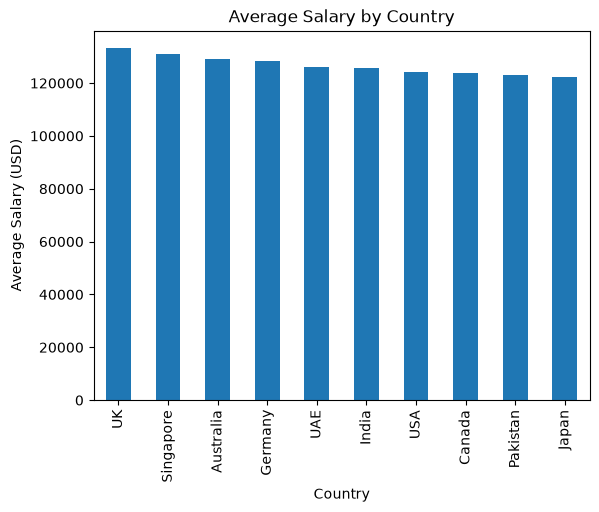

In [4]:
salary_by_country = (df.groupby("Country")["Average_Salary_USD"].mean().sort_values(ascending=False))
salary_by_country.plot(kind ="bar")
plt.title("Average Salary by Country")
plt.xlabel("Country")
plt.ylabel("Average Salary (USD)")
plt.show()

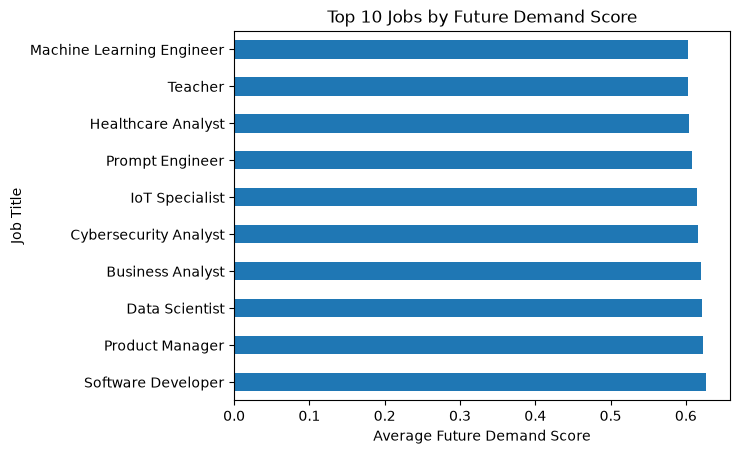

In [5]:
top_demand_jobs = (
    df.groupby("Job_Title")["Future_Demand_Score"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_demand_jobs.plot(kind="barh")

plt.title("Top 10 Jobs by Future Demand Score")
plt.xlabel("Average Future Demand Score")
plt.ylabel("Job Title")

plt.show()

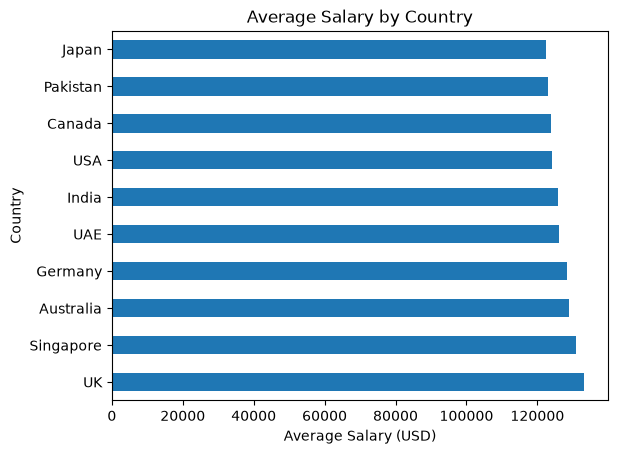

In [6]:
df.groupby("Country")["Average_Salary_USD"].mean().sort_values(ascending=False).head(10).plot(kind="barh")
plt.title("Average Salary by Country")
plt.xlabel("Average Salary (USD)")
plt.ylabel("Country")
plt.show()

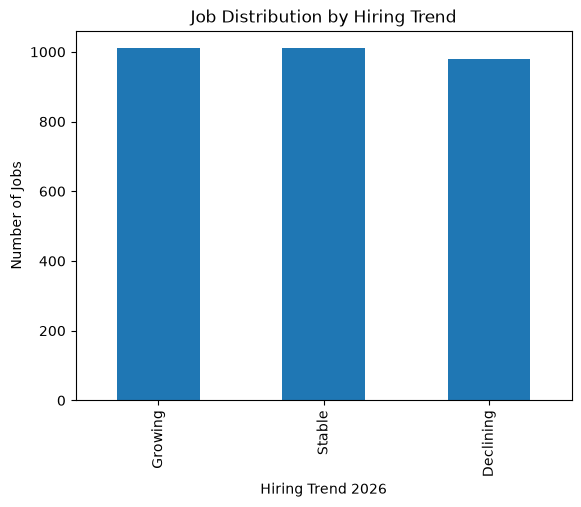

In [7]:
# How are jobs distributed across the three hiring trends: Growing, Stable, and Declining?

df["Hiring_Trend_2026"].value_counts().plot(kind="bar")
plt.title("Job Distribution by Hiring Trend") 
plt.xlabel("Hiring Trend 2026")
plt.ylabel("Number of Jobs")
plt.show()

In [8]:
df["Required_Skills"].head(5)

0                 Python, Communication, Deep Learning
1    Deep Learning, Azure, Communication, TensorFlo...
2    Kubernetes, Cloud Computing, TensorFlow, SQL, ...
3    Excel, Kubernetes, Prompt Engineering, Leadership
4           SQL, Leadership, TensorFlow, Cybersecurity
Name: Required_Skills, dtype: str

In [17]:
skill_counts = (
    df["Required_Skills"]
    .str.split(", ")
    .explode()
    .value_counts()
)

skill_counts.head(10)

Required_Skills
Cloud Computing       785
Leadership            778
Communication         776
Cybersecurity         776
Azure                 772
Deep Learning         770
Machine Learning      765
TensorFlow            762
Data Visualization    751
Kubernetes            750
Name: count, dtype: int64

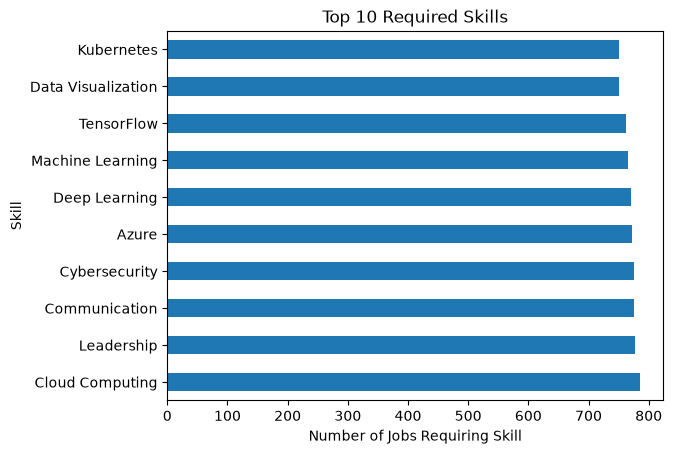

In [18]:
skill_counts.head(10).plot(kind="barh")
plt.title("Top 10 Required Skills")
plt.xlabel("Number of Jobs Requiring Skill")
plt.ylabel("Skill")
plt.show()

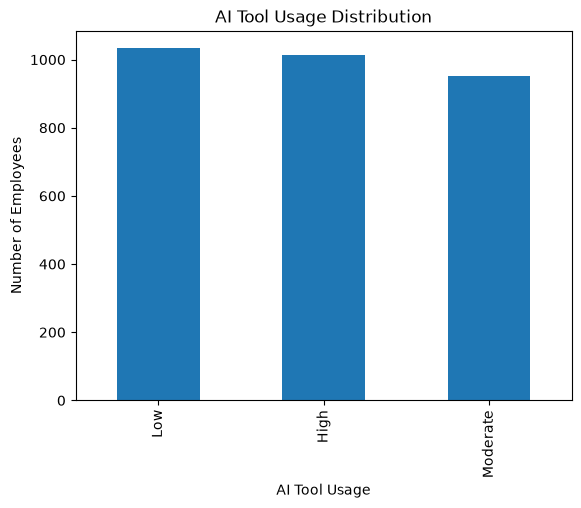

In [23]:
df["AI_Tool_Usage"].value_counts().plot(kind="bar")

plt.title("AI Tool Usage Distribution")
plt.xlabel("AI Tool Usage")
plt.ylabel("Number of Employees")

plt.show()

## Histogram

"A histogram groups numerical values into ranges (bins) and shows how frequently values occur within each range."
"The height of the bar shows how many values fall within that range (bin)."

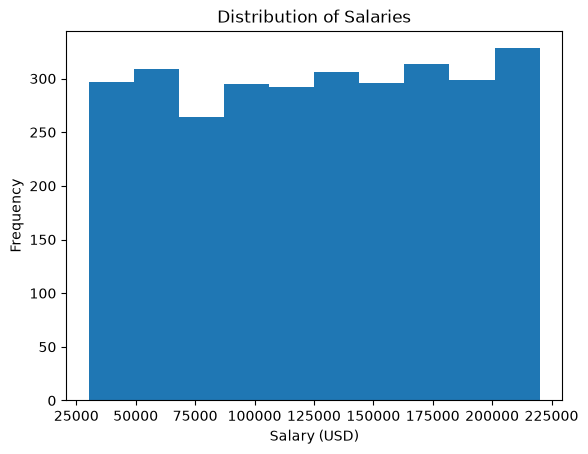

In [24]:
df["Average_Salary_USD"].plot(kind="hist")
plt.title("Distribution of Salaries")
plt.xlabel("Salary (USD)")
plt.ylabel("Frequency")
plt.show()

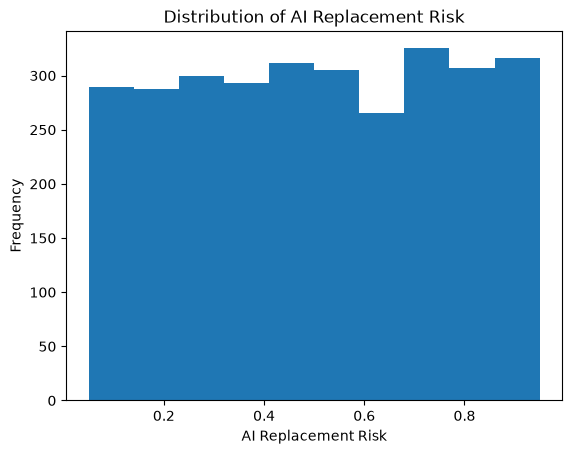

In [7]:
df["AI_Replacement_Risk"].plot(kind="hist")
plt.title("Distribution of AI Replacement Risk")
plt.xlabel("AI Replacement Risk")
plt.ylabel("Frequency")
plt.show()

## Box plot

A box plot will introduce you to:

median → quartiles → IQR → potential outliers

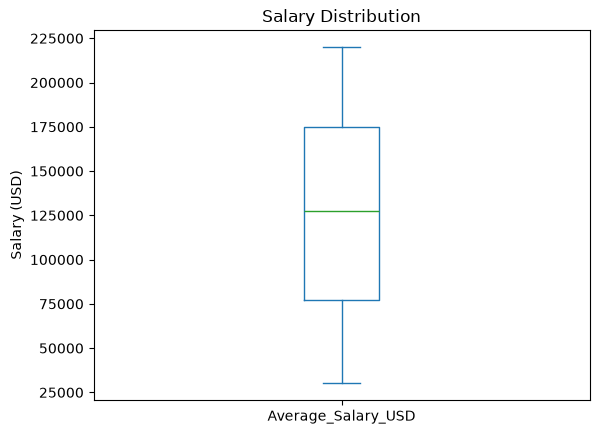

In [9]:
df["Average_Salary_USD"].plot(kind="box")

plt.title("Salary Distribution")
plt.ylabel("Salary (USD)")

plt.show()

In [12]:
Q1 = df["Average_Salary_USD"].quantile(0.25)
Q3 = df["Average_Salary_USD"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["Average_Salary_USD"] < lower_bound) |
    (df["Average_Salary_USD"] > upper_bound)
]

outliers

,Employee_ID,Job_Title,Industry,Country,Education_Level,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Remote_Work_Possibility,Average_Salary_USD,Required_Skills,Automation_Level,Job_Growth_2030,Work_Hours_Per_Week,Company_Size,AI_Tool_Usage,Performance_Score,Upskilling_Needed,Job_Satisfaction,Hiring_Trend_2026


Q: What did the salary box plot tell you in your AI Job Market project?

“The median salary was approximately $127,660, while Q1 and Q3 were approximately $77,262 and $174,812. This means the middle 50% of salaries fell within that range. I also checked potential outliers using the 1.5×IQR rule and found no apparent salary outliers.”

## Scatter Plot

Now we need a chart for a different question:

Are two numerical variables related to each other?

That's where a scatter plot is useful.

For example, in your dataset we can ask:

Do employees with more years of experience generally earn higher salaries?

<function matplotlib.pyplot.show(close=None, block=None)>

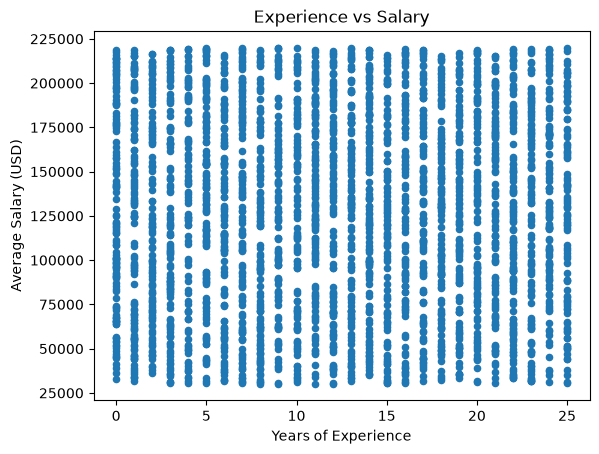

In [17]:
df.plot(
    kind="scatter",
    x="Years_Experience",
    y="Average_Salary_USD"
)

plt.title("Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Average Salary (USD)")

plt.show

1. Relationship: No obvious relationship. The points are widely scattered across almost every experience level, with no clear upward or downward pattern.

2. One dot: One observation/employee, representing that employee's Years_Experience on the x-axis and Average_Salary_USD on the y-axis.

3. Does more experience guarantee higher salary? Your reasoning is correct, but say:

“No. The scatter plot shows that employees at nearly every experience level have salaries across a wide range. There is no clear upward trend, so this dataset does not show an obvious relationship between experience and salary.”

A scatter plot gives us a visual indication of a relationship. We can also measure the strength of a linear relationship numerically:

df["Years_Experience"].corr(df["Average_Salary_USD"])

The correlation coefficient ranges from:

-1  ← strong negative relationship

 0  ← little/no linear relationship

+1  ← strong positive relationship

In [18]:
df["Years_Experience"].corr(df["Average_Salary_USD"])

np.float64(0.012794759324790551)

I first examined a scatter plot of years of experience versus salary and found no obvious trend. I then calculated the correlation coefficient, which was approximately 0.013. Since this is very close to zero, it supports the observation that there is little to no linear relationship between experience and salary in this dataset.

## Line Charts

A line chart is mainly useful when the x-axis has a meaningful order, especially time:

2022 → 2023 → 2024 → 2025 → 2026

It helps answer:

“How did something change over time?”

“I would use a line chart because the data is ordered by time, and a line chart clearly shows how revenue changes from one period to another, making the overall trend easy to identify.”

One extra point: a line chart is especially useful for spotting trends, increases/decreases, fluctuations, and changes over time.

## Exercise

<Axes: >

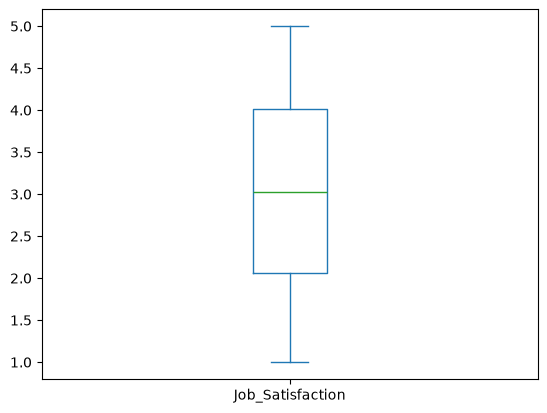

In [20]:
df["Job_Satisfaction"].plot(kind="box")

In [21]:
4.0-2.2


1.7999999999999998

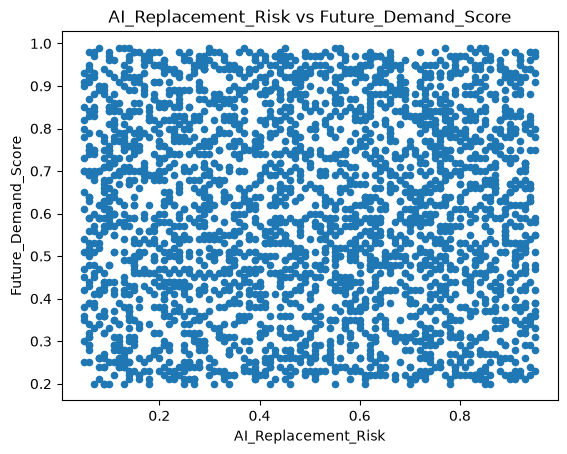

In [23]:
df.plot(
    kind="scatter",
    x="AI_Replacement_Risk",
    y="Future_Demand_Score"
)

plt.title("AI_Replacement_Risk vs Future_Demand_Score")
plt.xlabel("AI_Replacement_Risk")
plt.ylabel("Future_Demand_Score")

plt.show()

In [24]:
df["AI_Replacement_Risk"].corr(df["Future_Demand_Score"])

np.float64(0.007760674071424833)

In [25]:
df.columns

Index(['Employee_ID', 'Job_Title', 'Industry', 'Country', 'Education_Level',
       'Years_Experience', 'AI_Replacement_Risk', 'Future_Demand_Score',
       'Remote_Work_Possibility', 'Average_Salary_USD', 'Required_Skills',
       'Automation_Level', 'Job_Growth_2030', 'Work_Hours_Per_Week',
       'Company_Size', 'AI_Tool_Usage', 'Performance_Score',
       'Upskilling_Needed', 'Job_Satisfaction', 'Hiring_Trend_2026'],
      dtype='str')

<function matplotlib.pyplot.show(close=None, block=None)>

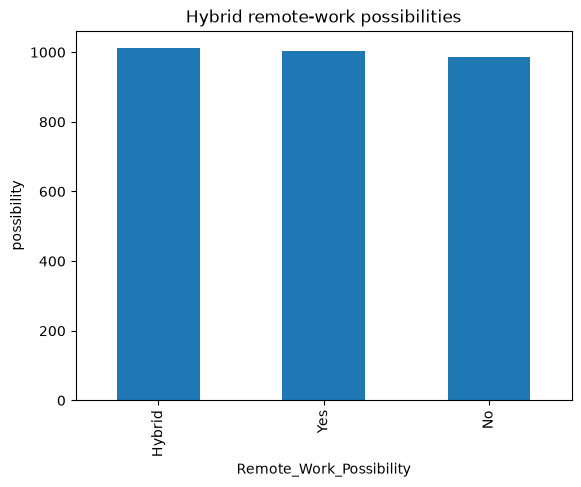

In [30]:
df["Remote_Work_Possibility"].value_counts().plot(kind="bar")

plt.title("Hybrid remote-work possibilities")
plt.xlabel("Remote_Work_Possibility")
plt.ylabel("possibility")

plt.show

In [31]:
df["Remote_Work_Possibility"].value_counts()

Remote_Work_Possibility
Hybrid    1011
Yes       1003
No         986
Name: count, dtype: int64